In [52]:
using Pkg
Pkg.instantiate()

In [53]:
using BootstrapAsymptotics
using QuadGK
using StableRNGs: StableRNG
using Plots
using Statistics
using ProgressBars

In [54]:
κ1    =  2.0 / sqrt(3* pi)
κstar = 0.200364

γ_range = 10 .^ range(-1, stop=5, length=500)
run_exp = false

sample_over_teacher = 5.0
Δ = 1.0
ρ = 1.0

1.0

In [66]:
# Run the BO estimation and check that we have same results as before 

bo_q0_list = []
bo_q1_list = []
bo_m_list = []
bo_v_list = []

for γ in ProgressBar(γ_range)
    problem = BootstrapAsymptotics.build_ridge_overparametrized(
        α = sample_over_teacher / γ,
        true_Δ = Δ,
        Δ̂ = nothing,
        λ = nothing,
        true_ρ = 1.0,
        κ1 = κ1,
        κstar = κstar,
        student_over_teacher_dim = γ,
        base_optimal = true
        )
    
    result = BootstrapAsymptotics.state_evolution(problem, NoResampling(), NoResampling(); max_iteration=1000, rtol=0.0)

    push!(bo_q0_list, result.overlaps.Q[1, 1])
    push!(bo_q1_list, result.overlaps.Q[1, 2])
    push!(bo_m_list, result.overlaps.m[1])
    push!(bo_v_list, result.overlaps.V[1])
end

0.0%┣                                              ┫ 0/500 [00:00<00:00, -0s/it]
2.2%┣█                                           ┫ 11/500 [00:00<00:03, 193it/s]
5.0%┣██▏                                         ┫ 25/500 [00:00<00:03, 138it/s]
8.0%┣███▌                                        ┫ 40/500 [00:00<00:03, 173it/s]
11.0%┣████▊                                      ┫ 55/500 [00:00<00:02, 194it/s]
14.0%┣██████                                     ┫ 70/500 [00:00<00:02, 210it/s]
17.4%┣███████▌                                   ┫ 87/500 [00:00<00:02, 225it/s]
20.6%┣████████▋                                 ┫ 103/500 [00:00<00:02, 234it/s]
23.6%┣██████████                                ┫ 118/500 [00:00<00:02, 240it/s]
26.6%┣███████████▏                              ┫ 133/500 [00:01<00:01, 245it/s]
29.6%┣████████████▍                             ┫ 148/500 [00:01<00:01, 249it/s]
32.6%┣█████████████▊                            ┫ 163/500 [00:01<00:01, 252it/s]
35.6%┣███████████████       

---

In [77]:
algos = [
    NoResampling(),
    PairBootstrap(),
]

# for λ << 1

q0_list_dict = Dict()
for algo in algos
    q0_list_dict[algo] = []
end

q1_list_dict = Dict()
for algo in algos
    q1_list_dict[algo] = []
end

m_list_dict = Dict()
for algo in algos
    m_list_dict[algo] = []
end

# same but for optmial λ

optimal_λ_q0_list_dict = Dict()
for algo in algos
    optimal_λ_q0_list_dict[algo] = []
end

optimal_λ_q1_list_dict = Dict()
for algo in algos
    optimal_λ_q1_list_dict[algo] = []
end

optimal_λ_m_list_dict = Dict()
for algo in algos
    optimal_λ_m_list_dict[algo] = []
end

# 

optimal_λ_scaling_list_dict = Dict()
for algo in algos
    optimal_λ_scaling_list_dict[algo] = []
end

scaling_list_dict = Dict()
for algo in algos
    scaling_list_dict[algo] = []
end

λ = 1e-10
optimal_λ_list = []

for γ in ProgressBar(γ_range)
    Δ_add = BootstrapAsymptotics.get_additional_noise_from_kappas(κ1, κstar, γ)
    λ_optimal = BootstrapAsymptotics.compute_optimal_λ(sample_over_student_dim = sample_over_teacher / γ, Δ = Δ, ρ = ρ, κ1 = κ1, κstar = κstar, student_over_teacher_dim = γ)
    push!(optimal_λ_list, λ_optimal)

    # 
    problem_λ_optimal = BootstrapAsymptotics.build_ridge_overparametrized(
        α = sample_over_teacher / γ,
        true_Δ = Δ,
        Δ̂ = 1.0,
        λ = λ_optimal,
        true_ρ = 1.0,
        κ1 = κ1,
        κstar = κstar,
        student_over_teacher_dim = γ,
    )

    for algo in algos
        result = BootstrapAsymptotics.state_evolution(
            problem_λ_optimal, algo, algo; rtol = 1e-8
        )
        push!(optimal_λ_q0_list_dict[algo], result.overlaps.Q[1, 1])
        push!(optimal_λ_q1_list_dict[algo], result.overlaps.Q[1, 2])
        push!(optimal_λ_m_list_dict[algo], result.overlaps.m[1])
        push!(optimal_λ_scaling_list_dict[algo], BootstrapAsymptotics.get_scaling_gaussian_nll(result.overlaps, problem_λ_optimal))
    end

    # 
    problem = BootstrapAsymptotics.build_ridge_overparametrized(
        α = sample_over_teacher / γ,
        true_Δ = Δ,
        Δ̂ = 1.0,
        λ = λ,
        true_ρ = 1.0,
        κ1 = κ1,
        κstar = κstar,
        student_over_teacher_dim = γ,
    )

    for algo in algos
        result = BootstrapAsymptotics.state_evolution(
            problem, algo, algo; rtol = 1e-8, max_iteration = 2000
        )
        push!(q0_list_dict[algo], result.overlaps.Q[1, 1])
        push!(q1_list_dict[algo], result.overlaps.Q[1, 2])
        push!(m_list_dict[algo], result.overlaps.m[1])
        push!(scaling_list_dict[algo], BootstrapAsymptotics.get_scaling_gaussian_nll(result.overlaps, problem))
    end
end

0.0%┣                                              ┫ 0/500 [00:00<00:00, -0s/it]
0.2%┣                                          ┫ 1/500 [00:00<Inf:Inf, InfGs/it]
25.4%┣██████████▊                               ┫ 127/500 [00:00<00:01, 469it/s]
34.4%┣██████████████▌                           ┫ 172/500 [00:00<00:01, 536it/s]
49.8%┣█████████████████████                     ┫ 249/500 [00:00<00:00, 670it/s]
65.4%┣███████████████████████████▌              ┫ 327/500 [00:00<00:00, 775it/s]
84.8%┣███████████████████████████████████▋      ┫ 424/500 [00:00<00:00, 897it/s]
92.8%┣███████████████████████████████████████   ┫ 464/500 [00:01<00:00, 873it/s]
100.0%┣█████████████████████████████████████████┫ 500/500 [00:01<00:00, 922it/s]
100.0%┣█████████████████████████████████████████┫ 500/500 [00:01<00:00, 922it/s]


In [88]:
# ===== plot before scaling =====

plot(size=(500, 500))

for algo in algos
    plot!(γ_range, optimal_λ_q0_list_dict[algo] .- optimal_λ_q1_list_dict[algo], label = "$algo, Optimal λ", linestyle = :dash)
    plot!(γ_range, q0_list_dict[algo] .- q1_list_dict[algo], label = "$algo, λ = $λ", linestyle = :dash)
end

plot!(γ_range, bo_q0_list .- bo_q1_list, label = "BO ensemble variance", color = :black)

plot!(title="Variance before scaling, n/d = $sample_over_teacher Δ = $Δ", xscale=:log10, yscale=:log10, xlabel="γ", ylabel="Ensemble variance", legend=:bottomleft)
# save the figure in plots/random_features folder
savefig("plots/ensemble_variance_before_scaling_n_d=$(sample_over_teacher)_Δ=$Δ.png")

"/Users/lucasclarte/Code/EPFL/Uncertainty/BootstrapAsymptotics/experiments/plots/ensemble_variance_before_scaling_n_d=5.0_Δ=1.0.png"

In [90]:
# ===== plot after scaling =====
plot(size=(500, 500))

for algo in algos
    plot!(γ_range, (optimal_λ_q0_list_dict[algo] .- optimal_λ_q1_list_dict[algo]) ./ optimal_λ_scaling_list_dict[algo], label = "$algo, Optimal λ", linestyle = :dash)
    plot!(γ_range, (q0_list_dict[algo] .- q1_list_dict[algo]) ./ scaling_list_dict[algo], label = "$algo, λ = $λ", linestyle = :dash)
end

plot!(γ_range, bo_v_list .+ Δ, label = "BO prediction variance", color = :black)

plot!(title="Ensemble variance, n/d = $sample_over_teacher, Δ=$Δ", xscale=:log10, yscale=:log10, xlabel="γ", ylabel="Ensemble variance", legend=:topright)
# save the figure in plots/random_features folder
savefig("plots/ensemble_variance_after_scaling_n_d=$(sample_over_teacher)_Δ=$Δ.png")

"/Users/lucasclarte/Code/EPFL/Uncertainty/BootstrapAsymptotics/experiments/plots/ensemble_variance_after_scaling_n_d=5.0_Δ=1.0.png"

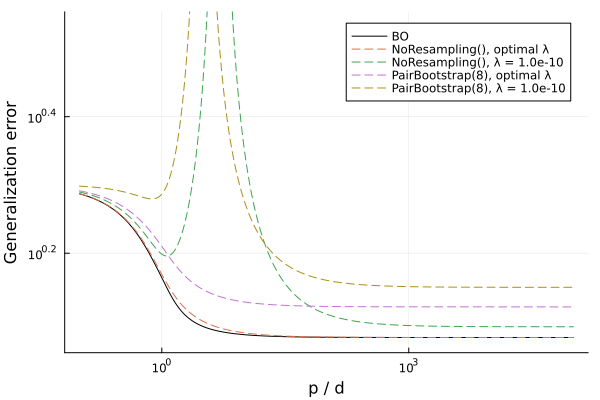

In [95]:
# plot the generalization error 
bo_gen_err = ρ .+ Δ .- 2.0 * bo_m_list .+ bo_q0_list

optimal_λ_gen_err_dict = Dict(algo => ρ .+ Δ .- 2.0 * optimal_λ_m_list_dict[algo] + optimal_λ_q0_list_dict[algo] for algo in algos)
gen_err_dict = Dict(algo => ρ .+ Δ .- 2.0 * m_list_dict[algo] + q0_list_dict[algo] for algo in algos)

plot(γ_range, bo_gen_err, label = "BO", color = :black, xlabel="p / d", ylabel="Generalization error", xscale=:log10, yscale=:log10)
for algo in algos
    plot!(γ_range, optimal_λ_gen_err_dict[algo], label = "$algo, optimal λ", linestyle = :dash)
    plot!(γ_range, gen_err_dict[algo], label = "$algo, λ = $λ", linestyle = :dash)
end

display(plot!(ylim = minimum(bo_gen_err) * [0.95, 3.0]))

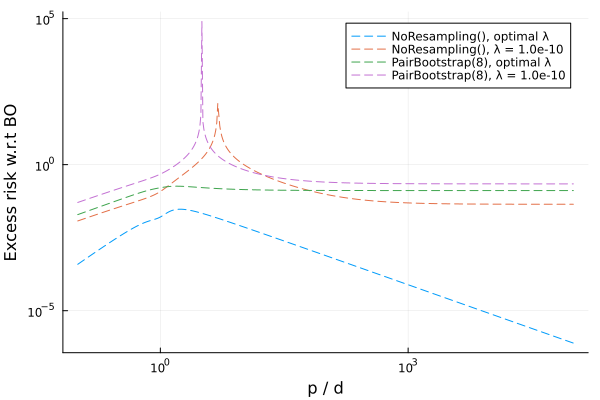

In [81]:
plot(xscale=:log10, yscale=:log10, xlabel="p / d", ylabel="Excess risk w.r.t BO")
for algo in algos
    plot!(γ_range, optimal_λ_gen_err_dict[algo] .- bo_gen_err, label = "$algo, optimal λ", linestyle = :dash)
    plot!(γ_range, gen_err_dict[algo] .- bo_gen_err, label = "$algo, λ = $λ", linestyle = :dash)
end
display(plot!())